## Hodgkin & Huxley model

$$C_m\frac{dV}{dt}=-g_{Na}m^3h(V-E_{Na}) - g_Kn^4(V-E_K) - g_l (V-E_l) + I_{stim}(t)$$
$$\frac{dm}{dt}=\alpha_m(1-m) - \beta_mm$$
$$\frac{dh}{dt}=\alpha_h(1-h) - \beta_hh$$
$$\frac{dn}{dt}=\alpha_n(1-n) - \beta_nn$$

$$\alpha_n = \frac{0.01(v+55)}{1-exp(-(v+55)/10)} \quad
\beta_n = 0.125exp(-(v+65)/80)$$
$$\alpha_m = \frac{0.1(v+40)}{1-exp(-(v+40)/10)} \quad
\beta_m = 4exp(-(v+65)/18)$$
$$\alpha_h = 0.07exp(-(v+65)/20) \quad
\beta_h = \frac{1}{1+exp(-(v+35)/10)} $$

We will numerically solve the differential equations system using the Euler method, with integration step $\Delta t=0.05$ and total simulation time 15 milliseconds.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.executable

'C:\\Users\\Marilyn\\anaconda3\\python.exe'

In [2]:
# -------------------------
# AUX FUNCTIONS (gating rates)
# -------------------------
def alpha_n(v):
    return 0.01*(v+55)/(1-np.exp(-(v+55)/10))
def alpha_m(v):
    return 0.1*(v+40)/(1-np.exp(-(v+40)/10))
def alpha_h(v):
    return 0.07*np.exp(-(v+65)/20)
def beta_n(v):
    return 0.125*np.exp(-(v+65)/80)
def beta_m(v):
    return 4*np.exp(-(v+65)/18)
def beta_h(v):
    return 1/(1+np.exp(-(v+35)/10))

# ------------------------- 
# HH ODE system 
#------------------------- 
def HyH(Var, Iapp): 
    """ Hodgkin-Huxley dynamics (Euler method). 
    Input:
    Uses global parameters gK, gNa, gL, EK, ENa, EL
    Iapp: applied current stimulus (uA/cm^2 or consistent units)
    Output: 
    v: membrane voltage (mV) 
    n: K activation gate 
    m: Na activation gate 
    h: Na inactivation gate 
    """
    [v,n,m,h]=Var
    Imemb=-Iapp+gK*n**4*(v-EK)+gNa*m**3*h*(v-ENa)+gL*(v-EL)
    return np.array([-Imemb,
                alpha_n(v)*(1-n)-beta_n(v)*n,
                alpha_m(v)*(1-m)-beta_m(v)*m,
                alpha_h(v)*(1-h)-beta_h(v)*h])

# Model parameters
gK=36
gNa=120
gL=0.3

EK=-77
EL=-54.4
ENa=50 #mV


# ------------------------- 
# SIMULATION (parameters you want to move) 
# ------------------------- 
def simulate_hh( Iamp=10, Idel=2, Idur=5, Tstop=50, dt=0.05, v0=-65, do_plot=True ): 
    """ Simulate HH with a rectangular current pulse: 
    Istim(t) = Iamp for Idel < t < Idel+Idur, 
    Returns time, Var_t (columns: v, n, m, h). 
    """ 
    # Initial conditions 
    v = v0 
    n = 1/(1 + beta_n(v)/alpha_n(v)) 
    m = 1/(1 + beta_m(v)/alpha_m(v)) 
    h = 1/(1 + beta_h(v)/alpha_h(v)) 
    
    X = np.array([v, n, m, h], dtype=float) 
    time = np.arange(0, Tstop, dt) 
    Var_t = np.zeros((len(time), 4), dtype=float) 
    
    for i, t in enumerate(time): 
        Var_t[i] = X 
        Istim = Iamp * (t > Idel) * (t < (Idel + Idur)) 
        X = X + dt * HyH(X, Istim) 
        
    if do_plot:
        plt.clf()

        plt.subplot(3, 1, 1)
        plt.plot(time, Iamp*(time > Idel)*(time < (Idel + Idur)))
        plt.ylabel(r"$I_{stim}$")

        plt.subplot(3, 1, 2)
        plt.plot(time, Var_t[:, 0])
        plt.ylabel("V")

        plt.subplot(3, 1, 3)
        plt.plot(time, Var_t[:, 1:])
        plt.legend(("n", "m", "h"))
        plt.xlabel("time")

        plt.tight_layout()

    return time, Var_t

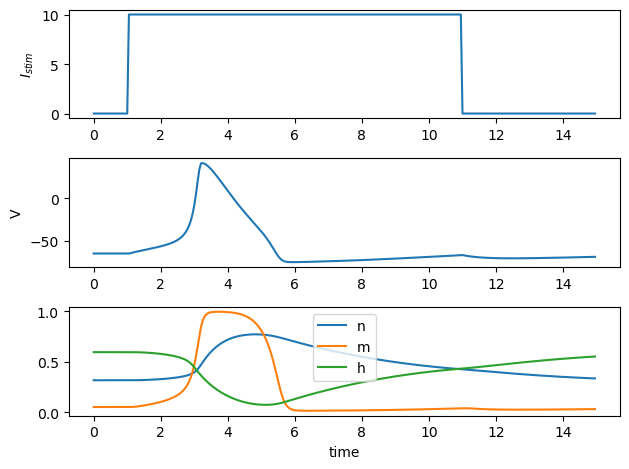

In [3]:
# Example runs 
time, Var_t = simulate_hh(Iamp=10, Idel=1, Idur=10, Tstop=15, dt=0.05)

### Longer simulation

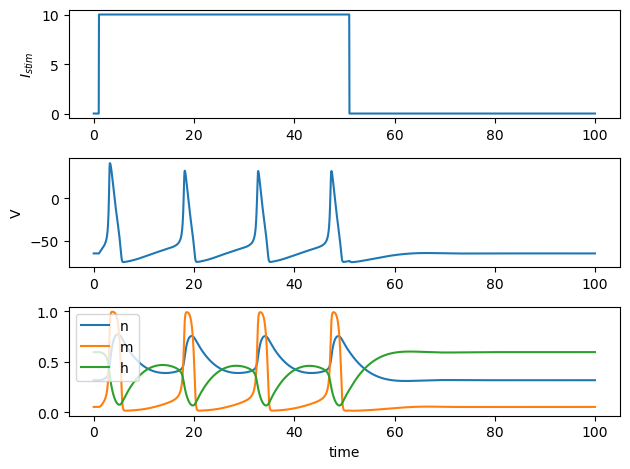

In [12]:
# Longer simulation
time, Var_t = simulate_hh(Iamp=10, Idel=1, Idur=50, Tstop=100, dt=0.05)

## Longer simulation with noise

In [14]:
# --- Simulation (same structure as before, now with noisy current) ---
def simulate_hh_noise(Iamp=10, Idel=1, Idur=50, Tstop=100, dt=0.05, v0=-65,
                Ivar=0.0, seed=None, do_plot=True):
    """
    Hodgkin–Huxley with rectangular current pulse and additive Gaussian noise.

    Iapp(t) = Imean(t) + sqrt(Ivar/dt) * N(0,1)

    Ivar: noise intensity (sigma^2) of white noise.
          Ivar = 0 gives the deterministic HH model.
    """

    if seed is not None:
        np.random.seed(seed)

    # Initial conditions
    v = v0
    n = 1/(1 + beta_n(v)/alpha_n(v))
    m = 1/(1 + beta_m(v)/alpha_m(v))
    h = 1/(1 + beta_h(v)/alpha_h(v))

    X = np.array([v, n, m, h], float)
    time = np.arange(0, Tstop, dt)
    Var_t = np.zeros((len(time), 4), float)
    I_t = np.zeros(len(time), float)

    # Noise scaling (Euler–Maruyama)
    sqdt = np.sqrt(Ivar/dt) if Ivar > 0 else 0.0

    for i, t in enumerate(time):
        Var_t[i] = X

        # deterministic stimulus
        Imean = Iamp*(t > Idel)*(t < (Idel + Idur))

        # noisy current
        I = Imean + sqdt*np.random.randn()
        I_t[i] = I

        # Euler–Maruyama step
        X = X + dt*HyH(X, I)

    if do_plot:
        plt.clf()
        plt.subplot(3,1,1)
        plt.plot(time, I_t)
        plt.ylabel(r"$I_{app}$")

        plt.subplot(3,1,2)
        plt.plot(time, Var_t[:,0])
        plt.ylabel("V")

        plt.subplot(3,1,3)
        plt.plot(time, Var_t[:,1:])
        plt.legend(("n","m","h"))
        plt.xlabel("time")
        plt.tight_layout()

    return time, Var_t, I_t


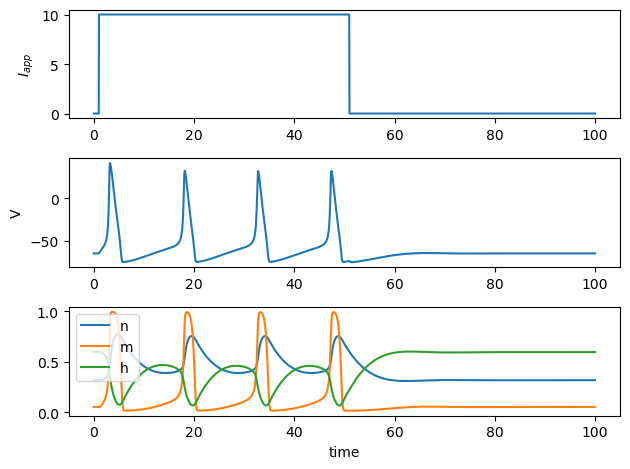

In [15]:
#Deterministic case
time, Var_t, I_t = simulate_hh_noise(Iamp=10, Idel=1, Idur=50, Ivar=0)


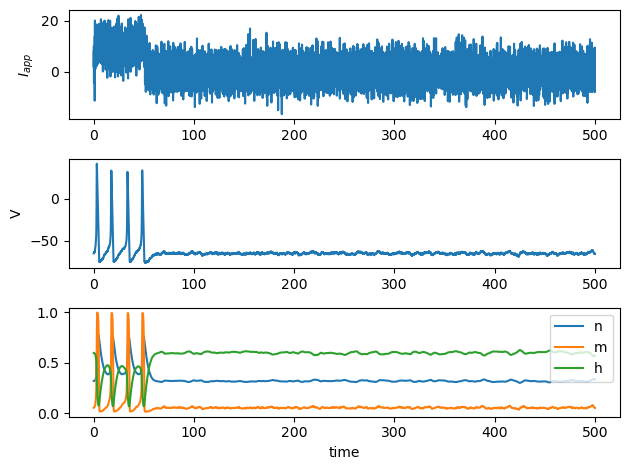

In [16]:
#A bit of noise
time, Var_t, I_t = simulate_hh_noise(Iamp=10, Idel=1, Idur=50,
                               Ivar=1, dt=0.05, seed=0,Tstop=500)


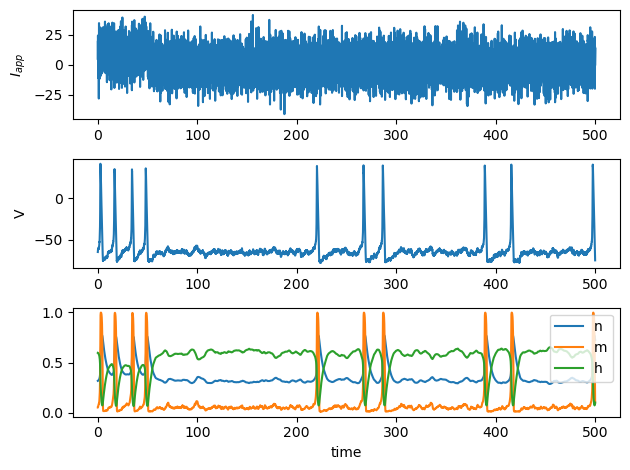

In [18]:
#Noisy
time, Var_t, I_t = simulate_hh_noise(Iamp=10, Idel=1, Idur=50,
                               Ivar=6, seed=0,Tstop=500)